In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/lakshmisaivarshiniy/pa-amr-metadata/BVBRC_Nepal_Metadata.csv
/kaggle/input/datasets/lakshmisaivarshiniy/pa-amr-metadata/BVBRC_Nepal_SpecialtyGenes.csv
/kaggle/input/datasets/lakshmisaivarshiniy/pa-amr-metadata/NCBI_India_Metadata.csv
/kaggle/input/datasets/lakshmisaivarshiniy/pa-amr-metadata/BVBRC_India_Metadata.csv
/kaggle/input/datasets/lakshmisaivarshiniy/pa-amr-metadata/PubMLST_India.xlsx
/kaggle/input/datasets/lakshmisaivarshiniy/pa-amr-metadata/BVBRC_Bangladesh_Metadata.csv
/kaggle/input/datasets/lakshmisaivarshiniy/pa-amr-metadata/BVBRC_India_SpecialtyGenes.csv
/kaggle/input/datasets/lakshmisaivarshiniy/pa-amr-metadata/BVBRC_India_AMRPhenotypes.csv
/kaggle/input/datasets/lakshmisaivarshiniy/pa-amr-metadata/BVBRC_Pakistan_SpecialtyGenes.csv
/kaggle/input/datasets/lakshmisaivarshiniy/pa-amr-metadata/BVBRC_Pakistan_AMRPhenotypes.csv
/kaggle/input/datasets/lakshmisaivarshiniy/pa-amr-metadata/BVBRC_Bangladesh_SpecialtyGenes.csv
/kaggle/input/datasets/lakshmisai

In [2]:
# CELL 1: IMPORTS AND PATH SETUP
# Analysis of Emerging AMR Genes in South Asian P. aeruginosa
# Author: Y. Lakshmi Sai Varshini
# Institution: SRM Institute of Science and Technology
# Supervisor: Dr. P. Rathinasabapathi
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import re
import os
import warnings
warnings.filterwarnings('ignore')

# ── File paths ───────────────────────────────────────────────
META_PATH   = '/kaggle/input/datasets/lakshmisaivarshiniy/pa-amr-metadata'
AMR_PATH    = '/kaggle/input/datasets/lakshmisaivarshiniy/pa-amr-staramr'
OUT_PATH    = '/kaggle/working'

# ── Plot styling ─────────────────────────────────────────────
plt.rcParams['figure.dpi']    = 150
plt.rcParams['font.family']   = 'DejaVu Sans'
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

print("All libraries loaded successfully")
print(f"Matplotlib version: {plt.matplotlib.__version__}")
print(f"Pandas version: {pd.__version__}")

All libraries loaded successfully
Matplotlib version: 3.10.0
Pandas version: 2.3.3


In [3]:
# CELL 2: LOAD METADATA FROM ALL THREE DATABASES
# ============================================================

# ── BV-BRC Metadata (4 countries) ───────────────────────────
bvbrc_india      = pd.read_csv(f'{META_PATH}/BVBRC_India_Metadata.csv', low_memory=False)
bvbrc_pakistan   = pd.read_csv(f'{META_PATH}/BVBRC_Pakistan_Metadata.csv', low_memory=False)
bvbrc_bangladesh = pd.read_csv(f'{META_PATH}/BVBRC_Bangladesh_Metadata.csv', low_memory=False)
bvbrc_nepal      = pd.read_csv(f'{META_PATH}/BVBRC_Nepal_Metadata.csv', low_memory=False)

# Combine all BV-BRC
bvbrc = pd.concat([bvbrc_india, bvbrc_pakistan, bvbrc_bangladesh, bvbrc_nepal], ignore_index=True)
print(f"BV-BRC total rows: {len(bvbrc)}")
print(f"BV-BRC columns: {list(bvbrc.columns[:10])}")

# ── NCBI Metadata ────────────────────────────────────────────
ncbi = pd.read_csv(f'{META_PATH}/NCBI_India_Metadata.csv', low_memory=False)
print(f"\nNCBI total rows: {len(ncbi)}")
print(f"NCBI columns: {list(ncbi.columns[:10])}")

BV-BRC total rows: 355
BV-BRC columns: ['Genome ID', 'Genome Name', 'Other Names', 'NCBI Taxon ID', 'Taxon Lineage IDs', 'Taxon Lineage Names', 'Superkingdom', 'Kingdom', 'Phylum', 'Class']

NCBI total rows: 41
NCBI columns: ['Assembly Name', 'Assembly Accession', 'Assembly Paired Assembly Accession', 'Organism Name', 'Organism Infraspecific Names Strain', 'Annotation Name', 'Assembly Level', 'Assembly Release Date', 'WGS project accession', 'Assembly Stats Number of Scaffolds']


In [4]:
# CELL 3: CURATE METADATA — EXTRACT GCA, COUNTRY, YEAR, ST
# ============================================================

# ── BV-BRC: Extract relevant columns ─────────────────────────
# Check what columns have accession and year info
print("BV-BRC relevant columns:")
relevant = [c for c in bvbrc.columns if any(x in c.lower() for x in 
            ['accession','assembly','year','date','collection','mlst','country','isolation','host'])]
print(relevant)

BV-BRC relevant columns:
['MLST', 'Culture Collection', 'Completion Date', 'BioProject Accession', 'BioSample Accession', 'Assembly Accession', 'SRA Accession', 'GenBank Accessions', 'Assembly Method', 'Isolation Source', 'Isolation Comments', 'Collection Date', 'Collection Year', 'Isolation Country', 'Host Name', 'Host Common Name', 'Host Sex', 'Host Age', 'Host Health', 'Host Group', 'Lab Host', 'Date Inserted', 'Date Modified']


In [5]:
# CELL 3B: BUILD MASTER METADATA TABLE
# ============================================================

# ── BV-BRC: Extract key columns ──────────────────────────────
bvbrc_clean = bvbrc[['Assembly Accession', 'Isolation Country', 
                      'Collection Year', 'MLST', 'Host Name',
                      'Isolation Source']].copy()
bvbrc_clean.columns = ['GCA', 'Country', 'Year', 'MLST_raw', 'Host', 'Source']

# Fix country names
bvbrc_clean['Country'] = bvbrc_clean['Country'].replace({
    'India': 'India',
    'Pakistan': 'Pakistan',
    'Bangladesh': 'Bangladesh',
    'Nepal': 'Nepal'
})

# ── NCBI: Extract key columns ────────────────────────────────
print("NCBI relevant columns:")
ncbi_relevant = [c for c in ncbi.columns if any(x in c.lower() for x in
                ['accession','assembly','year','date','collection','country','isolation'])]
print(ncbi_relevant)

NCBI relevant columns:
['Assembly Name', 'Assembly Accession', 'Assembly Paired Assembly Accession', 'Assembly Level', 'Assembly Release Date', 'WGS project accession', 'Assembly Stats Number of Scaffolds', 'Assembly BioSample Accession', 'Collection Date']


In [6]:
# CELL 4: BUILD COMPLETE MASTER METADATA TABLE
# ============================================================

# ── NCBI: Extract key columns ────────────────────────────────
ncbi_clean = ncbi[['Assembly Accession', 'Collection Date']].copy()
ncbi_clean.columns = ['GCA', 'Year_raw']

def extract_year(val):
    if pd.isna(val):
        return None
    m = re.search(r'(\d{4})', str(val))
    return int(m.group(1)) if m else None

ncbi_clean['Year'] = ncbi_clean['Year_raw'].apply(extract_year)
ncbi_clean['Country'] = 'India'
ncbi_clean['MLST_raw'] = None
ncbi_clean['Host'] = 'Human'
ncbi_clean['Source'] = 'NCBI'
ncbi_clean = ncbi_clean[['GCA', 'Country', 'Year', 'MLST_raw', 'Host', 'Source']]

# ── BV-BRC: Add source tag ────────────────────────────────────
bvbrc_clean['Year'] = pd.to_numeric(bvbrc_clean['Year'], errors='coerce')
bvbrc_clean['Source'] = 'BV-BRC'

# ── Merge BV-BRC and NCBI ────────────────────────────────────
bvbrc_gcas = set(bvbrc_clean['GCA'].dropna())
ncbi_unique = ncbi_clean[~ncbi_clean['GCA'].isin(bvbrc_gcas)]
print(f"NCBI unique genomes not in BV-BRC: {len(ncbi_unique)}")

meta = pd.concat([bvbrc_clean, ncbi_unique], ignore_index=True)

# ── Extract ST from MLST column ──────────────────────────────
def extract_st(val):
    if pd.isna(val):
        return 'ND'
    m = re.search(r'\.(\d+)$', str(val))
    return m.group(1) if m else 'ND'

meta['ST'] = meta['MLST_raw'].apply(extract_st)

# ── ST to CC mapping ─────────────────────────────────────────
st_to_cc = {
    '175':'CC175','253':'CC175','111':'CC111','235':'CC235',
    '244':'CC244','308':'CC308','17':'CC17','146':'CC146',
    '155':'CC155','274':'CC274','395':'CC395','549':'CC549',
    '664':'CC664','316':'CC316','357':'CC357','654':'CC654',
    '823':'CC823','1047':'CC1047','1203':'CC1203','303':'CC303',
    '313':'CC313','532':'CC532','491':'CC491','241':'CC241',
    '760':'CC760','773':'CC773','639':'CC639'
}
meta['CC'] = meta['ST'].map(st_to_cc).fillna('ND')

# ── Assign time bins ─────────────────────────────────────────
bins   = [1994, 1999, 2004, 2009, 2014, 2019, 2024]
labels = ['1995-1999','2000-2004','2005-2009','2010-2014','2015-2019','2020-2024']
meta['TimeBin'] = pd.cut(meta['Year'], bins=bins, labels=labels)

# ── Filter human clinical isolates only ──────────────────────
meta_clinical = meta[
    meta['Host'].str.contains('human|Human|Homo', na=False) |
    meta['Source'].eq('NCBI')
].copy()

print(f"Total metadata rows: {len(meta)}")
print(f"Human clinical isolates: {len(meta_clinical)}")
print(f"\nCountry distribution:")
print(meta_clinical['Country'].value_counts())
print(f"\nTime bin distribution:")
print(meta_clinical['TimeBin'].value_counts().sort_index())

NCBI unique genomes not in BV-BRC: 41
Total metadata rows: 396
Human clinical isolates: 396

Country distribution:
Country
India         365
Pakistan       21
Bangladesh      9
Nepal           1
Name: count, dtype: int64

Time bin distribution:
TimeBin
1995-1999      9
2000-2004      6
2005-2009     17
2010-2014     32
2015-2019    134
2020-2024    198
Name: count, dtype: int64


In [7]:
# CELL 5: LOAD AND CLEAN STARAMR RESFINDER OUTPUT
# ============================================================

# ── Load resfinder output ────────────────────────────────────
resfinder = pd.read_csv(f'{AMR_PATH}/resfinder.tsv', sep='\t', low_memory=False)
print(f"Raw resfinder rows: {len(resfinder)}")
print(f"Columns: {list(resfinder.columns)}")
print(f"\nFirst row sample:")
print(resfinder.iloc[0])

Raw resfinder rows: 2906
Columns: ['Isolate ID', 'Gene', 'Predicted Phenotype', 'CGE Predicted Phenotype', '%Identity', '%Overlap', 'HSP Length/Total Length', 'Contig', 'Start', 'End', 'Accession', 'Sequence', 'CGE Notes']

First row sample:
Isolate ID                              GCA_000399805.1_Pseudoaeru02_genomic
Gene                                                             aph(3')-IIb
Predicted Phenotype                                                kanamycin
CGE Predicted Phenotype                               Unknown Aminoglycoside
%Identity                                                              99.26
%Overlap                                                               100.0
HSP Length/Total Length                                              807/807
Contig                                                        AQHM01000163.1
Start                                                                  22143
End                                                              

In [8]:
# CELL 6: EXTRACT GCA, CLEAN GENE NAMES, REMOVE INTRINSIC
# ============================================================

# ── Extract GCA accession from Isolate ID ────────────────────
def extract_gca(isolate_id):
    m = re.match(r'(GCA_\d+\.\d+)', str(isolate_id))
    return m.group(1) if m else None

resfinder['GCA'] = resfinder['Isolate ID'].apply(extract_gca)

# ── Clean gene names (remove allele suffix _1, _3 etc) ───────
resfinder['Gene_clean'] = resfinder['Gene'].str.replace(r'_\d+$', '', regex=True)

# ── Define intrinsic genes to remove ─────────────────────────
intrinsic_patterns = [
    r'^blaPAO', r'^blaOXA-50', r'^blaOXA-395', r'^blaOXA-396',
    r'^blaOXA-486', r'^blaOXA-488', r'^blaOXA-494',
    r"^fosA", r'^catB7', r"^aph\(3'\)-IIb"
]

def is_intrinsic(gene):
    for p in intrinsic_patterns:
        if re.search(p, str(gene)):
            return True
    return False

resfinder['Intrinsic'] = resfinder['Gene_clean'].apply(is_intrinsic)

# ── Split into intrinsic and acquired ────────────────────────
intrinsic_df = resfinder[resfinder['Intrinsic'] == True].copy()
rf = resfinder[resfinder['Intrinsic'] == False].copy()

print(f"Raw detections: {len(resfinder)}")
print(f"Intrinsic detections removed: {len(intrinsic_df)}")
print(f"Acquired ARG detections remaining: {len(rf)}")
print(f"\nIntrinsic genes removed:")
print(intrinsic_df['Gene_clean'].value_counts())
print(f"\nTop 10 acquired ARGs:")
print(rf['Gene_clean'].value_counts().head(10))

Raw detections: 2906
Intrinsic detections removed: 1357
Acquired ARG detections remaining: 1549

Intrinsic genes removed:
Gene_clean
aph(3')-IIb    280
blaPAO         274
fosA           273
catB7          253
blaOXA-50       93
blaOXA-488      65
blaOXA-395      53
blaOXA-494      34
blaOXA-486      17
blaOXA-396      15
Name: count, dtype: int64

Top 10 acquired ARGs:
Gene_clean
sul1           190
tet(G)          98
CmlA9           96
aph(3'')-Ib     82
aph(6)-Id       81
crpP            74
blaOXA-10       68
aac(6')-Il      62
rmtF            55
aac(6')-Ib3     43
Name: count, dtype: int64


In [9]:
# CELL 7: MERGE ARG DATA WITH METADATA
# ============================================================

# ── Merge rf with metadata on GCA ────────────────────────────
rf = rf.merge(
    meta_clinical[['GCA', 'Country', 'Year', 'TimeBin', 'ST', 'CC']],
    on='GCA', how='left'
)

# ── Assign drug classes ───────────────────────────────────────
def get_drug_class(gene):
    g = str(gene).lower()
    if g.startswith('bla'):                                    return 'beta-lactam'
    if any(g.startswith(x) for x in ['aac','aph','ant','aad','rmt','str']): return 'aminoglycoside'
    if any(g.startswith(x) for x in ['sul']):                 return 'sulfonamide'
    if any(g.startswith(x) for x in ['tet']):                 return 'tetracycline'
    if any(g.startswith(x) for x in ['qnr','crpp']):          return 'fluoroquinolone'
    if any(g.startswith(x) for x in ['dfr']):                 return 'trimethoprim'
    if any(g.startswith(x) for x in ['mph','msr','ere','erm']): return 'macrolide'
    if any(g.startswith(x) for x in ['arr']):                 return 'rifampicin'
    if any(g.startswith(x) for x in ['cmla','flor','catb','cmx','cml']): return 'phenicol'
    return 'other'

rf['DrugClass'] = rf['Gene_clean'].apply(get_drug_class)

print(f"Total rows after merge: {len(rf)}")
print(f"\nDrug class distribution:")
print(rf['DrugClass'].value_counts())
print(f"\nGenomes with acquired ARGs: {rf['GCA'].nunique()}")
print(f"\nUnique acquired ARGs: {rf['Gene_clean'].nunique()}")

Total rows after merge: 1549

Drug class distribution:
DrugClass
aminoglycoside     559
beta-lactam        235
sulfonamide        199
phenicol           139
tetracycline       133
fluoroquinolone    106
trimethoprim        80
macrolide           54
other               25
rifampicin          19
Name: count, dtype: int64

Genomes with acquired ARGs: 201

Unique acquired ARGs: 94


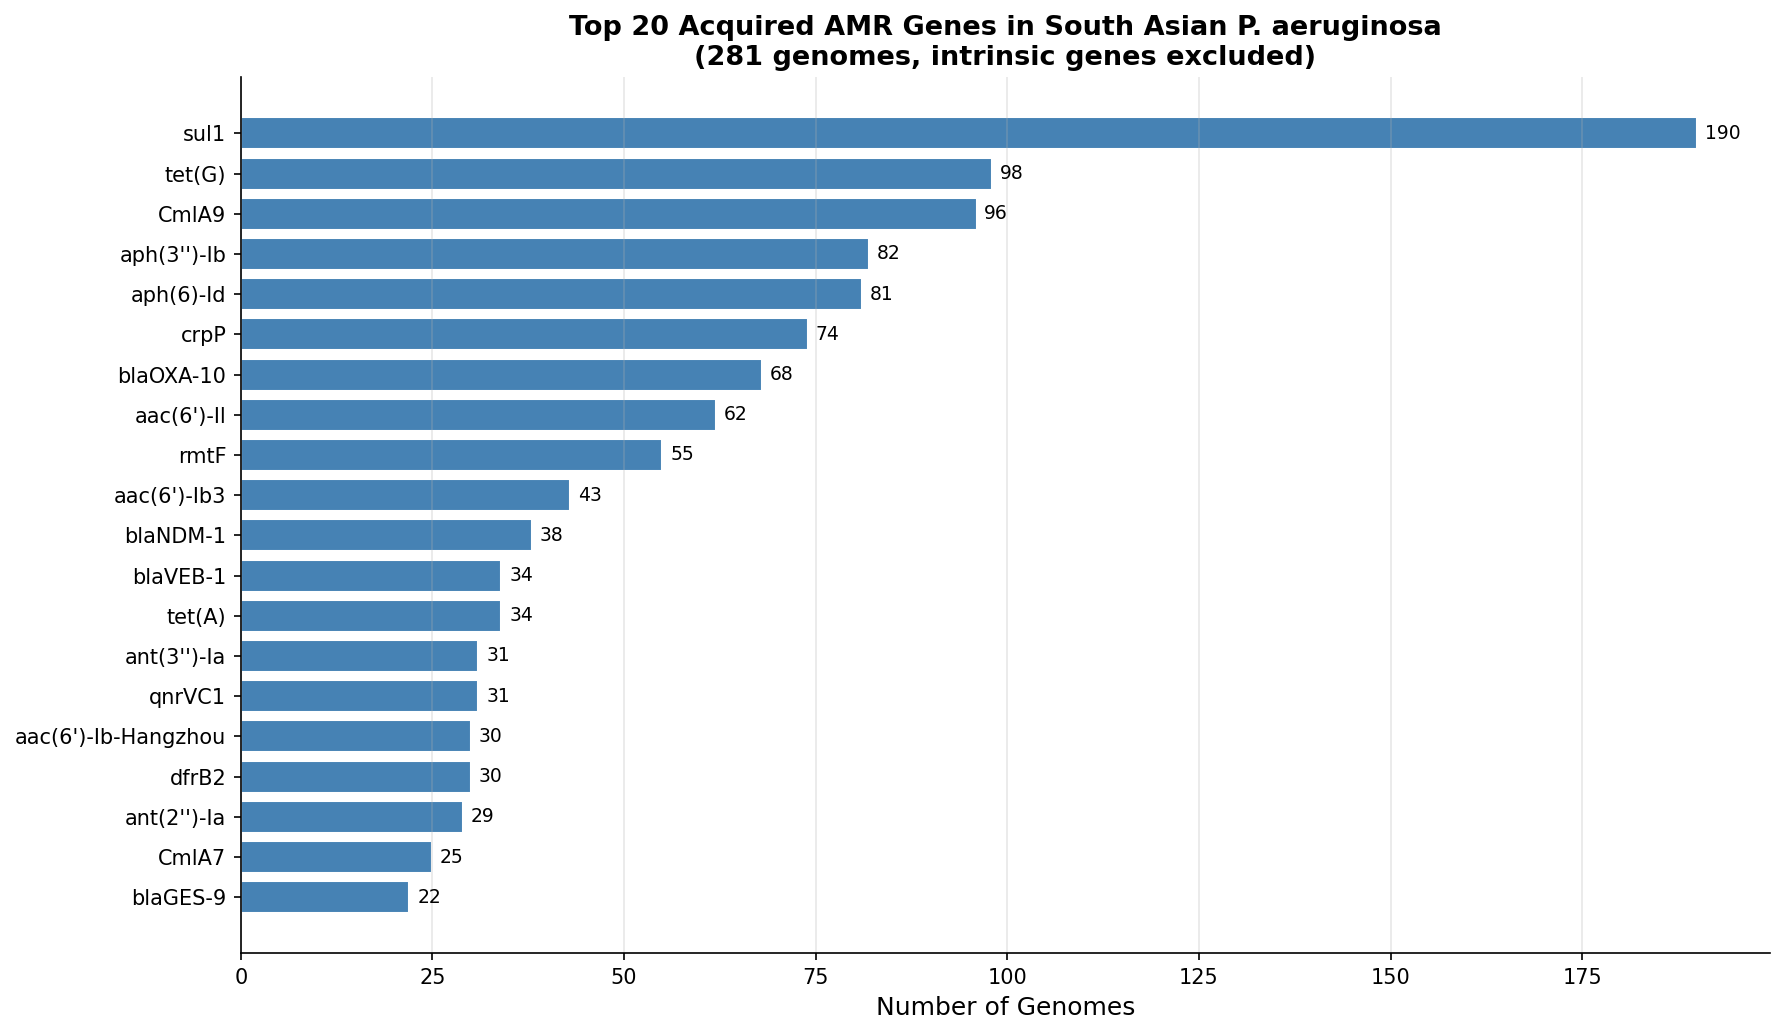

Figure 1 saved


In [10]:
# CELL 8: FIGURE 1 — TOP 20 ACQUIRED ARGs BAR CHART
# ============================================================

top20 = rf['Gene_clean'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top20.index[::-1], top20.values[::-1], color='steelblue', edgecolor='white')

ax.set_xlabel('Number of Genomes', fontsize=12)
ax.set_title('Top 20 Acquired AMR Genes in South Asian P. aeruginosa\n(281 genomes, intrinsic genes excluded)',
             fontsize=13, fontweight='bold')

for bar, val in zip(bars, top20.values[::-1]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9)

ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUT_PATH}/Fig1_Top20_ARGs.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 1 saved")

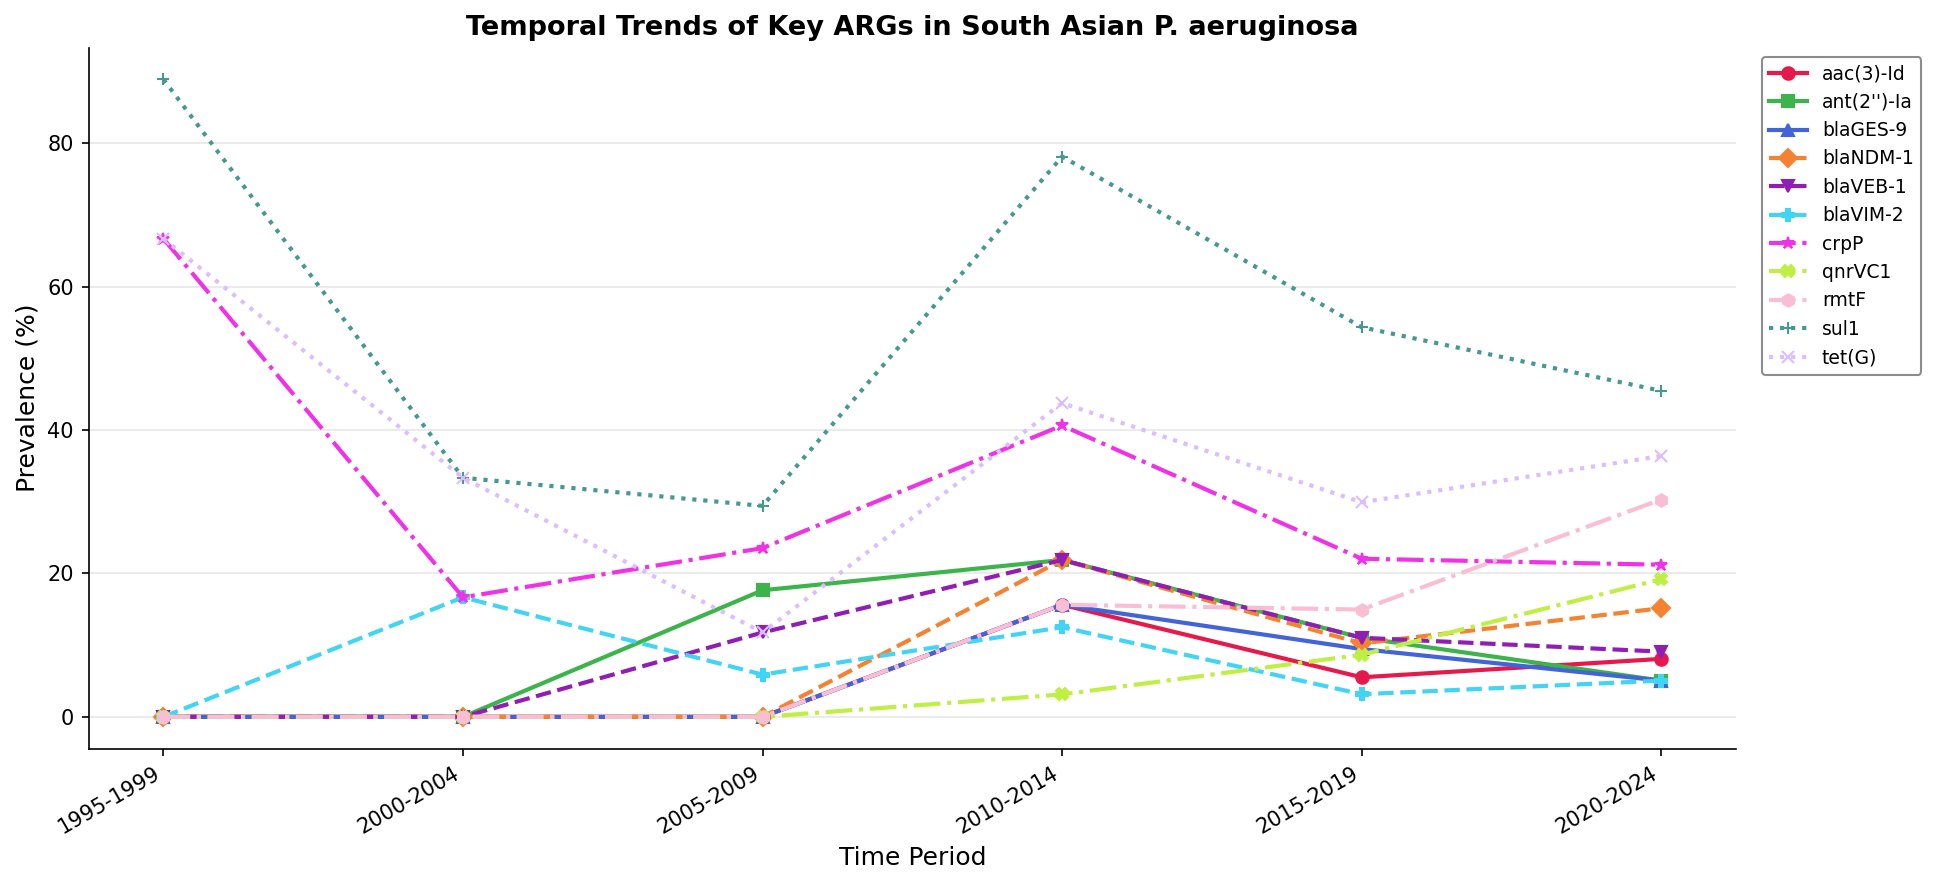

Figure 2 saved


In [11]:
# CELL 9: FIGURE 2 — TEMPORAL TRENDS
# ============================================================

focus_genes = ['blaNDM-1', 'blaVIM-2', 'rmtF', 'sul1', 'tet(G)',
               'qnrVC1', 'blaGES-9', 'blaVEB-1', "ant(2'')-Ia",
               'aac(3)-Id', 'crpP']

rf_focus = rf[rf['Gene_clean'].isin(focus_genes)].copy()

temporal = (rf_focus.groupby(['TimeBin', 'Gene_clean'])['GCA']
            .nunique().reset_index(name='Count'))

total_per_bin = (meta_clinical.groupby('TimeBin')['GCA']
                 .nunique().reset_index(name='Total'))

temporal = temporal.merge(total_per_bin, on='TimeBin')
temporal['Prevalence'] = temporal['Count'] / temporal['Total'] * 100

pivot_temp = temporal.pivot(index='TimeBin', columns='Gene_clean',
                            values='Prevalence').fillna(0)

# Manually distinct colors
distinct_colors = [
    '#e6194b', '#3cb44b', '#4363d8', '#f58231', '#911eb4',
    '#42d4f4', '#f032e6', '#bfef45', '#fabed4', '#469990', '#dcbeff'
]

# Line styles for extra distinction
linestyles = ['-', '-', '-', '--', '--', '--', '-.', '-.', '-.', ':', ':']
markers = ['o', 's', '^', 'D', 'v', 'P', '*', 'X', 'h', '+', 'x']

fig, ax = plt.subplots(figsize=(13, 6))

for i, gene in enumerate(pivot_temp.columns):
    ax.plot(range(len(pivot_temp.index)), pivot_temp[gene],
            marker=markers[i % len(markers)],
            label=gene,
            color=distinct_colors[i % len(distinct_colors)],
            linestyle=linestyles[i % len(linestyles)],
            linewidth=2, markersize=6)

ax.set_xticks(range(len(pivot_temp.index)))
ax.set_xticklabels(pivot_temp.index, rotation=30, ha='right')
ax.set_xlabel('Time Period', fontsize=12)
ax.set_ylabel('Prevalence (%)', fontsize=12)
ax.set_title('Temporal Trends of Key ARGs in South Asian P. aeruginosa',
             fontsize=13, fontweight='bold')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9,
          framealpha=0.9, edgecolor='gray')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUT_PATH}/Fig2_Temporal_Trends.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 2 saved")

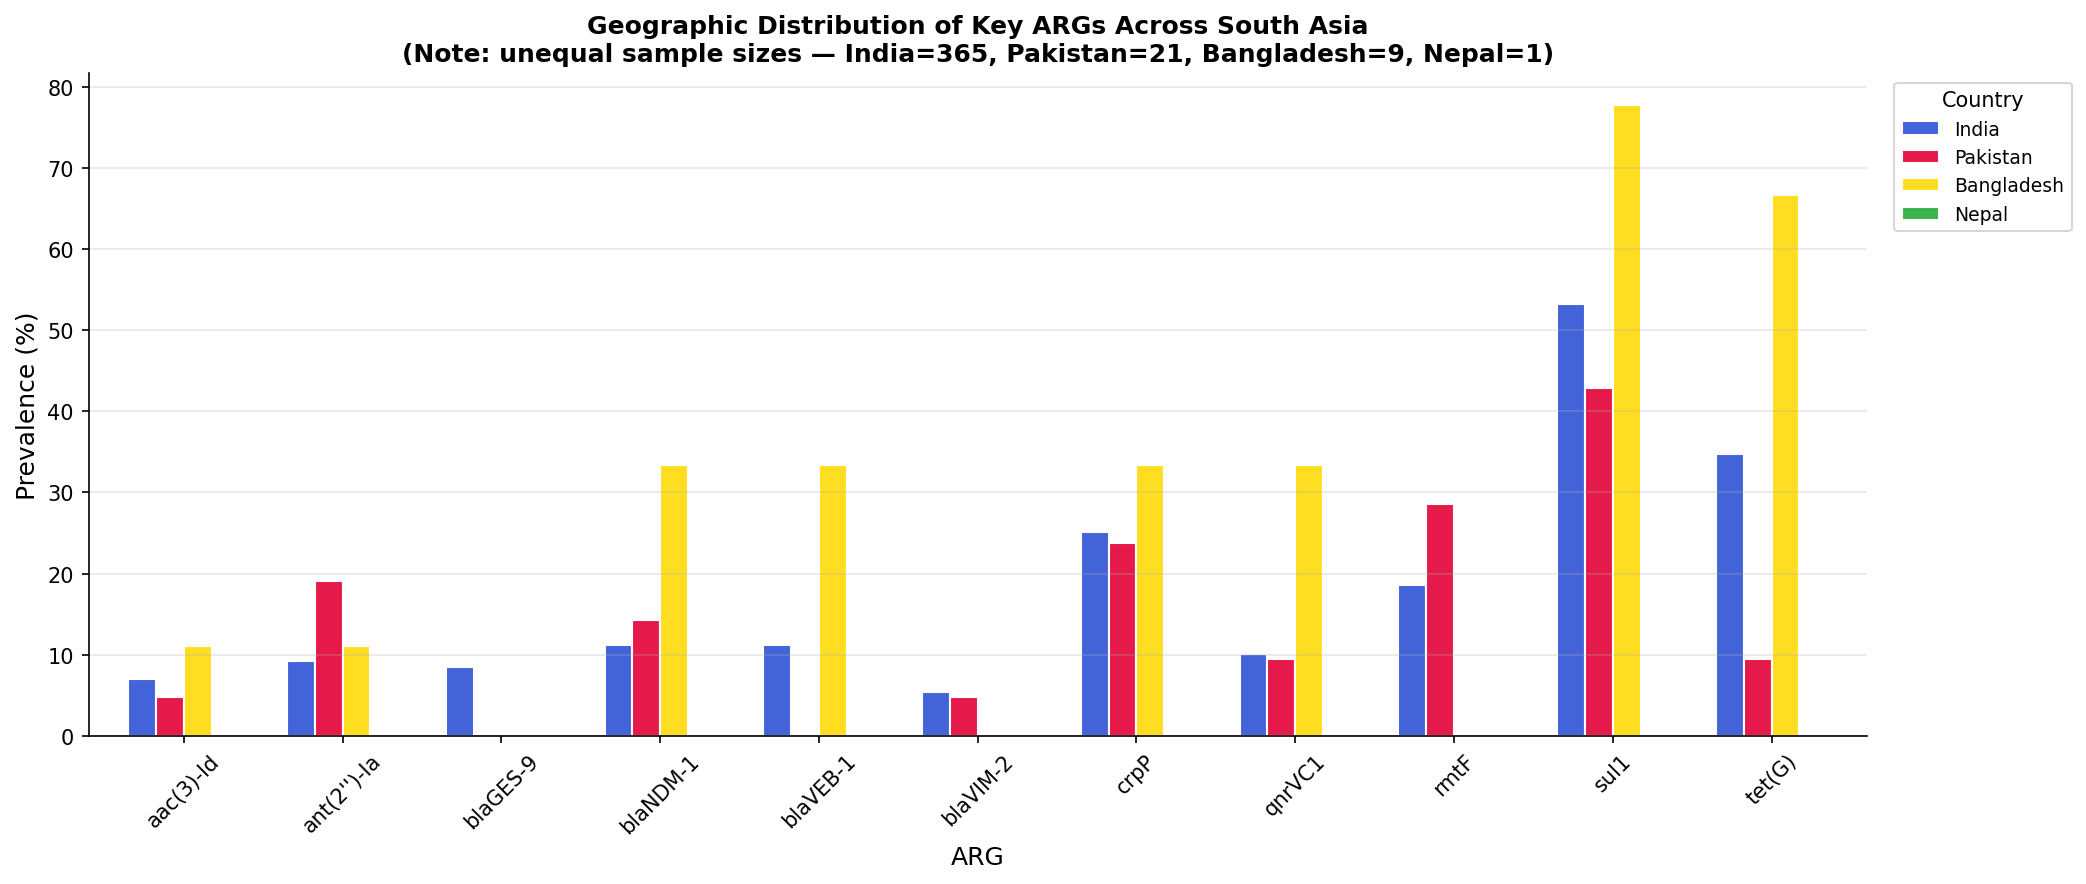

Figure 3 saved


In [12]:
# CELL 10: FIGURE 3 — GEOGRAPHIC DISTRIBUTION
# ============================================================

geo = (rf_focus.groupby(['Country', 'Gene_clean'])['GCA']
       .nunique().reset_index(name='Count'))

total_per_country = (meta_clinical.groupby('Country')['GCA']
                     .nunique().reset_index(name='Total'))

geo = geo.merge(total_per_country, on='Country')
geo['Prevalence'] = geo['Count'] / geo['Total'] * 100

pivot_geo = geo.pivot(index='Country', columns='Gene_clean',
                      values='Prevalence').fillna(0)
pivot_geo = pivot_geo.reindex(['India', 'Pakistan', 'Bangladesh', 'Nepal']).fillna(0)

fig, ax = plt.subplots(figsize=(14, 6))
pivot_geo.T.plot(kind='bar', ax=ax,
                 color=['#4363d8', '#e6194b', '#ffdE21', '#3cb44b'],
                 edgecolor='white', width=0.7)

ax.set_xlabel('ARG', fontsize=12)
ax.set_ylabel('Prevalence (%)', fontsize=12)
ax.set_title('Geographic Distribution of Key ARGs Across South Asia\n(Note: unequal sample sizes — India=365, Pakistan=21, Bangladesh=9, Nepal=1)',
             fontsize=12, fontweight='bold')
ax.legend(title='Country', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUT_PATH}/Fig3_Geographic_Distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 3 saved")

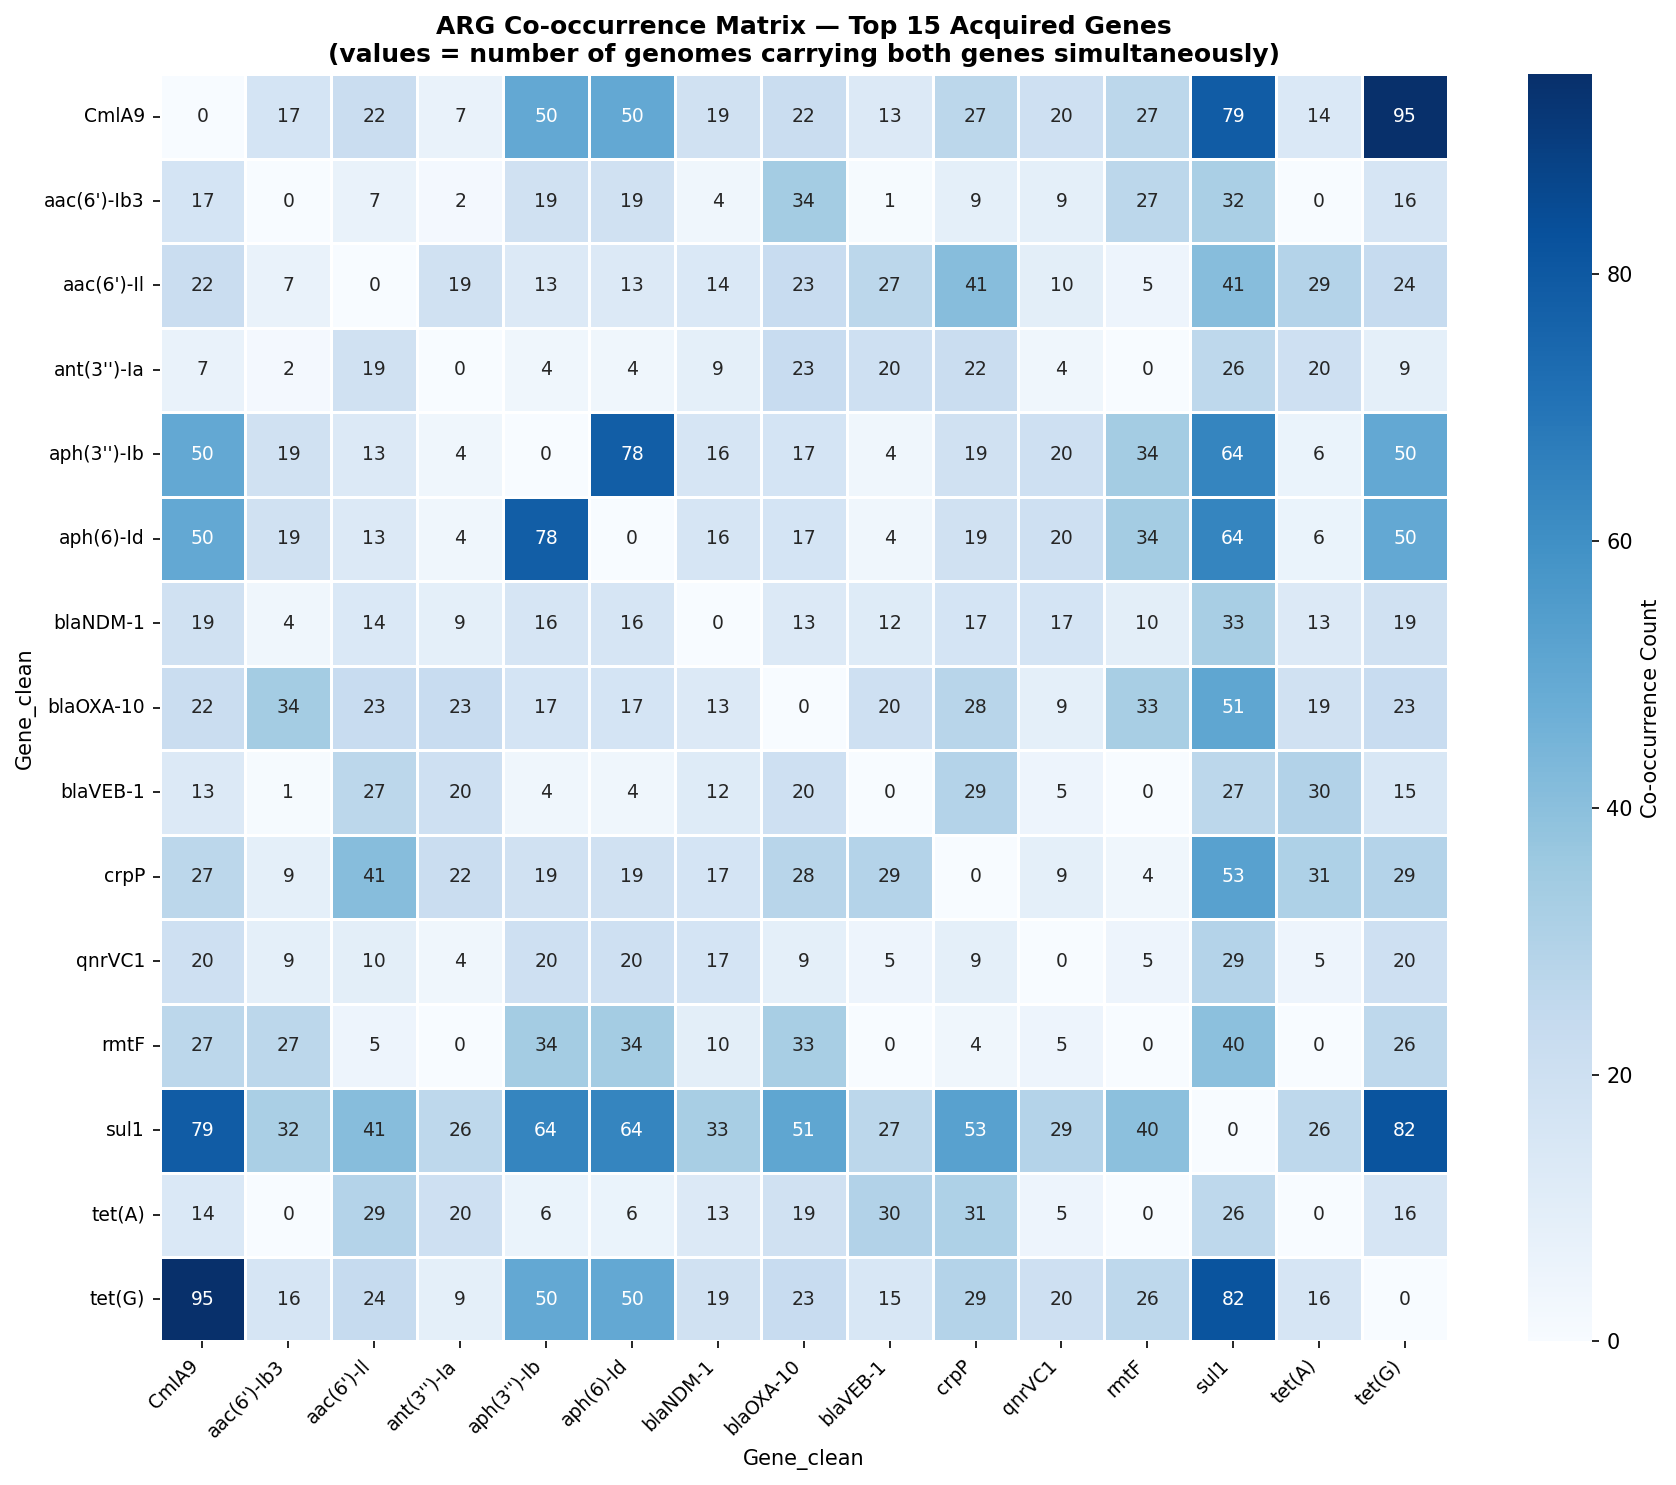

Figure 4 saved


In [13]:
# CELL 11: FIGURE 4 — CO-OCCURRENCE HEATMAP
# ============================================================

top15 = rf['Gene_clean'].value_counts().head(15).index.tolist()

pa_matrix = (rf[rf['Gene_clean'].isin(top15)]
             .groupby(['GCA', 'Gene_clean'])
             .size().unstack(fill_value=0).clip(upper=1))

cooccur = pa_matrix.T.dot(pa_matrix)
np.fill_diagonal(cooccur.values, 0)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cooccur, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Co-occurrence Count'},
            annot_kws={'size': 9})

ax.set_title('ARG Co-occurrence Matrix — Top 15 Acquired Genes\n(values = number of genomes carrying both genes simultaneously)',
             fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig(f'{OUT_PATH}/Fig4_Cooccurrence_Heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 4 saved")

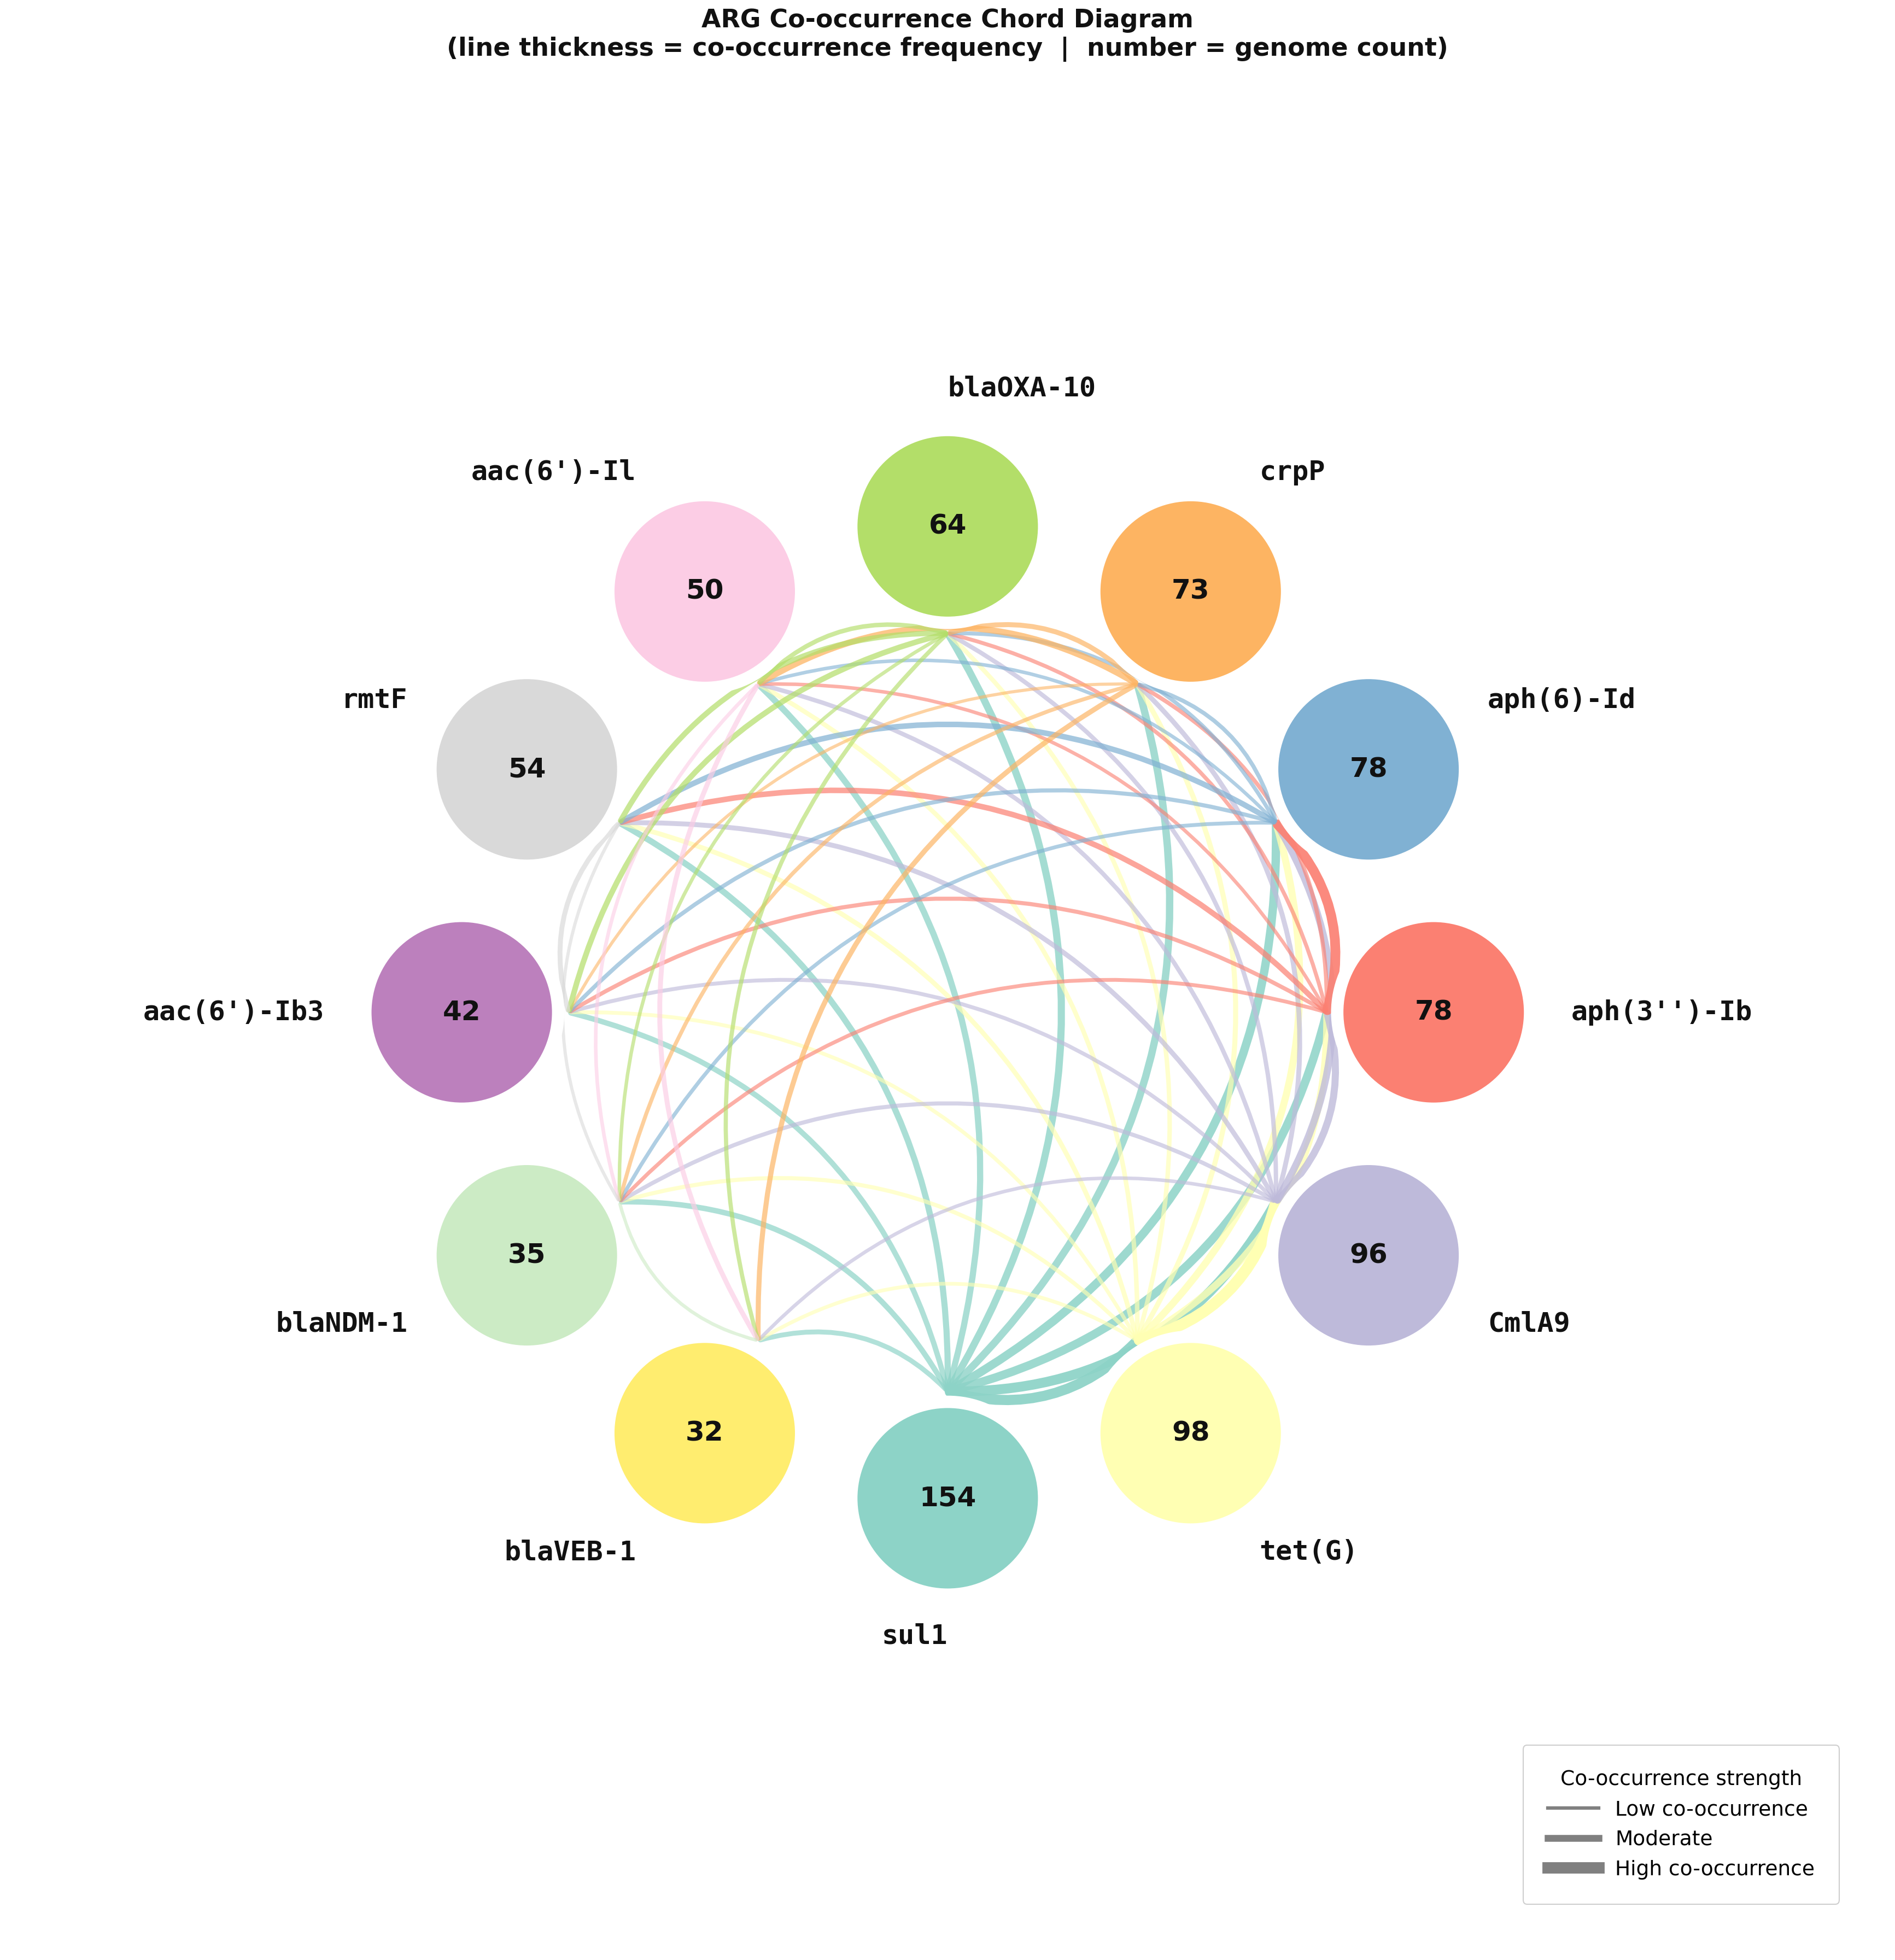

Figure 5 saved


In [14]:
# CELL 12: FIGURE 5 — CHORD DIAGRAM
# ============================================================

top12 = rf['Gene_clean'].value_counts().head(12).index.tolist()

pa_mat = (rf[rf['Gene_clean'].isin(top12)]
          .groupby(['GCA', 'Gene_clean'])
          .size().unstack(fill_value=0).clip(upper=1))
pa_mat = pa_mat.reindex(columns=top12, fill_value=0)

cooccur_c = pa_mat.T.dot(pa_mat).values.astype(float)
np.fill_diagonal(cooccur_c, 0)

n = len(top12)
colors = plt.cm.Set3(np.linspace(0, 1, n))

CHORD_R = 3.0
NODE_R  = 0.55
LABEL_R = 3.85

fig, ax = plt.subplots(figsize=(24, 24))
ax.set_aspect('equal')
ax.axis('off')
fig.patch.set_facecolor('white')
ax.set_xlim(-5.8, 5.8)
ax.set_ylim(-5.8, 5.8)

theta = np.linspace(0, 2*np.pi, n, endpoint=False) - np.pi/2
max_val = cooccur_c.max()

# ── Chords first ──────────────────────────────────────────────
for i in range(n):
    for j in range(i+1, n):
        val = cooccur_c[i, j]
        if val < 8:
            continue
        alpha = 0.55 + 0.45*(val/max_val)
        lw = 2 + 8*(val/max_val)
        ax.annotate("",
            xy=(np.cos(theta[j])*CHORD_R*0.78,
                np.sin(theta[j])*CHORD_R*0.78),
            xytext=(np.cos(theta[i])*CHORD_R*0.78,
                    np.sin(theta[i])*CHORD_R*0.78),
            arrowprops=dict(arrowstyle="-", color=colors[i],
                            alpha=alpha, lw=lw,
                            connectionstyle="arc3,rad=0.3"),
            zorder=1)

# ── Circles on top ────────────────────────────────────────────
for i, (gene, color) in enumerate(zip(top12, colors)):
    cx = np.cos(theta[i])*CHORD_R
    cy = np.sin(theta[i])*CHORD_R
    ax.add_patch(plt.Circle((cx, cy), NODE_R+0.08,
                             color='white', zorder=4))
    ax.add_patch(plt.Circle((cx, cy), NODE_R, color=color,
                             zorder=5, linewidth=2, edgecolor='white'))
    count = int(pa_mat[gene].sum())
    ax.text(cx, cy, str(count), ha='center', va='center',
            fontsize=24, fontweight='bold', color='#111111', zorder=6)

# ── Labels ────────────────────────────────────────────────────
for i, gene in enumerate(top12):
    angle = theta[i]
    lx = np.cos(angle)*LABEL_R
    ly = np.sin(angle)*LABEL_R
    angle_deg = np.degrees(angle)
    ha = 'left' if -90 < angle_deg <= 90 else 'right'
    ax.text(lx, ly, gene, ha=ha, va='center',
            fontsize=24, fontweight='bold', color='#111111',
            fontfamily='monospace', clip_on=False, zorder=7)

# ── Legend ────────────────────────────────────────────────────
ax.legend(handles=[
    plt.Line2D([0],[0], color='gray', lw=3,  label='Low co-occurrence'),
    plt.Line2D([0],[0], color='gray', lw=6,  label='Moderate'),
    plt.Line2D([0],[0], color='gray', lw=10, label='High co-occurrence'),
], loc='lower right', bbox_to_anchor=(0.98, 0.02),
   fontsize=18, framealpha=0.95,
   title='Co-occurrence strength', title_fontsize=18,
   borderpad=1.2, handlelength=2.5)

ax.set_title('ARG Co-occurrence Chord Diagram\n'
             '(line thickness = co-occurrence frequency  |  number = genome count)',
             fontsize=22, fontweight='bold', pad=15, color='#111111')

plt.tight_layout()
plt.savefig(f'{OUT_PATH}/Fig5_Chord_Diagram.png', dpi=200,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Figure 5 saved")

MDR burden per time bin:
  TimeBin  MeanDrugClasses
1995-1999         4.444444
2000-2004         3.666667
2005-2009         5.166667
2010-2014         4.821429
2015-2019         5.038462
2020-2024         4.298701


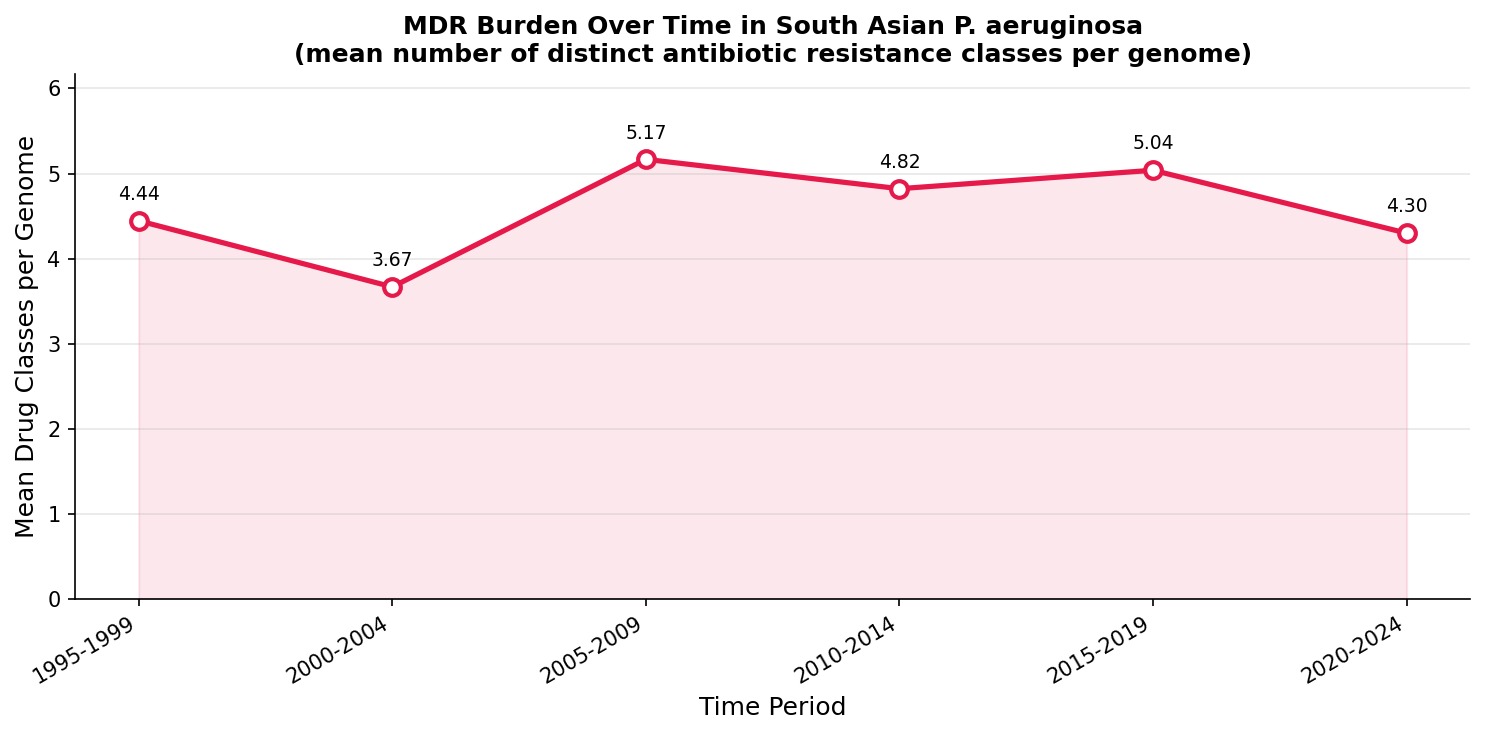

Figure 6 saved


In [15]:
# CELL 13: MDR BURDEN TREND OVER TIME
# ============================================================

# Calculate mean drug classes per genome per time bin
rf_known = rf[rf['DrugClass'] != 'other'].copy()

dc_per_genome = (rf_known.groupby('GCA')['DrugClass']
                 .nunique().reset_index(name='NumDrugClasses'))

dc_per_genome = dc_per_genome.merge(
    meta_clinical[['GCA', 'TimeBin']], on='GCA', how='left')

mdr_trend = (dc_per_genome.groupby('TimeBin')['NumDrugClasses']
             .mean().reset_index())
mdr_trend.columns = ['TimeBin', 'MeanDrugClasses']

print("MDR burden per time bin:")
print(mdr_trend.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(len(mdr_trend)), mdr_trend['MeanDrugClasses'],
        marker='o', color='#e6194b', linewidth=2.5,
        markersize=8, markerfacecolor='white', markeredgewidth=2)

ax.fill_between(range(len(mdr_trend)), mdr_trend['MeanDrugClasses'],
                alpha=0.1, color='#e6194b')

for i, row in mdr_trend.iterrows():
    ax.annotate(f"{row['MeanDrugClasses']:.2f}",
                xy=(i, row['MeanDrugClasses']),
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=9)

ax.set_xticks(range(len(mdr_trend)))
ax.set_xticklabels(mdr_trend['TimeBin'], rotation=30, ha='right')
ax.set_xlabel('Time Period', fontsize=12)
ax.set_ylabel('Mean Drug Classes per Genome', fontsize=12)
ax.set_title('MDR Burden Over Time in South Asian P. aeruginosa\n'
             '(mean number of distinct antibiotic resistance classes per genome)',
             fontsize=12, fontweight='bold')
ax.set_ylim(0, mdr_trend['MeanDrugClasses'].max() + 1)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUT_PATH}/Fig6_MDR_Burden_Trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 6 saved")

In [16]:
# CELL 14: STATISTICAL TESTS
# ============================================================

from scipy import stats

# ── ARG counts per genome ─────────────────────────────────────
arg_counts = (rf.groupby('GCA')['Gene_clean']
              .nunique().reset_index(name='ARG_count'))

arg_counts = arg_counts.merge(
    meta_clinical[['GCA', 'TimeBin', 'Country']], on='GCA', how='left')

# ── Test 1: Shapiro-Wilk normality test ──────────────────────
stat, p = stats.shapiro(arg_counts['ARG_count'])
print(f"Shapiro-Wilk Test (normality):")
print(f"  W = {stat:.4f}, p = {p:.4f}")
if p < 0.05:
    print(f"  Result: Non-normal distribution → use non-parametric tests")
else:
    print(f"  Result: Normal distribution")

# ── Test 2: Kruskal-Wallis across time bins ───────────────────
groups_time = [group['ARG_count'].values for name, group
               in arg_counts.groupby('TimeBin') if len(group) > 1]
h, p_time = stats.kruskal(*groups_time)
print(f"\nKruskal-Wallis Test (across time bins):")
print(f"  H = {h:.4f}, p = {p_time:.4f}")
if p_time < 0.05:
    print(f"  Result: Significant difference across time bins")
else:
    print(f"  Result: No significant difference — MDR is endemic and stable")

# ── Test 3: Mann-Whitney early vs recent ─────────────────────
early  = arg_counts[arg_counts['TimeBin'].isin(['1995-1999','2000-2004','2005-2009'])]['ARG_count']
recent = arg_counts[arg_counts['TimeBin'].isin(['2015-2019','2020-2024'])]['ARG_count']
u, p_mw = stats.mannwhitneyu(early, recent, alternative='two-sided')
print(f"\nMann-Whitney U Test (early 1995-2009 vs recent 2015-2024):")
print(f"  U = {u:.1f}, p = {p_mw:.4f}")
print(f"  Early median: {early.median():.1f} ARGs/genome")
print(f"  Recent median: {recent.median():.1f} ARGs/genome")
if p_mw < 0.05:
    print(f"  Result: Significant difference between early and recent")
else:
    print(f"  Result: No significant difference — resistance stable over time")

# ── Test 4: Kruskal-Wallis across countries ───────────────────
groups_country = [group['ARG_count'].values for name, group
                  in arg_counts.groupby('Country') if len(group) > 1]
h_c, p_c = stats.kruskal(*groups_country)
print(f"\nKruskal-Wallis Test (across countries):")
print(f"  H = {h_c:.4f}, p = {p_c:.4f}")
if p_c < 0.05:
    print(f"  Result: Significant difference across countries")
else:
    print(f"  Result: No significant difference — unequal sample sizes limit conclusions")

print("\n--- Statistical Summary ---")
print(f"All tests used non-parametric methods (Shapiro-Wilk confirmed non-normal distribution)")

Shapiro-Wilk Test (normality):
  W = 0.9674, p = 0.0001
  Result: Non-normal distribution → use non-parametric tests

Kruskal-Wallis Test (across time bins):
  H = 4.1411, p = 0.5293
  Result: No significant difference — MDR is endemic and stable

Mann-Whitney U Test (early 1995-2009 vs recent 2015-2024):
  U = 1309.5, p = 0.6716
  Early median: 6.0 ARGs/genome
  Recent median: 7.0 ARGs/genome
  Result: No significant difference — resistance stable over time

Kruskal-Wallis Test (across countries):
  H = 4.8636, p = 0.0879
  Result: No significant difference — unequal sample sizes limit conclusions

--- Statistical Summary ---
All tests used non-parametric methods (Shapiro-Wilk confirmed non-normal distribution)


Total genomes with ST assigned: 327

Top 15 Sequence Types:
  ST  Count ST_label
 357     51    ST357
1047     25   ST1047
 244     22    ST244
 664     22    ST664
 308     20    ST308
 235     20    ST235
1203     20   ST1203
 316     19    ST316
 654     12    ST654
 823      8    ST823
 773      8    ST773
 639      5    ST639
 303      5    ST303
 274      4    ST274
 207      3    ST207


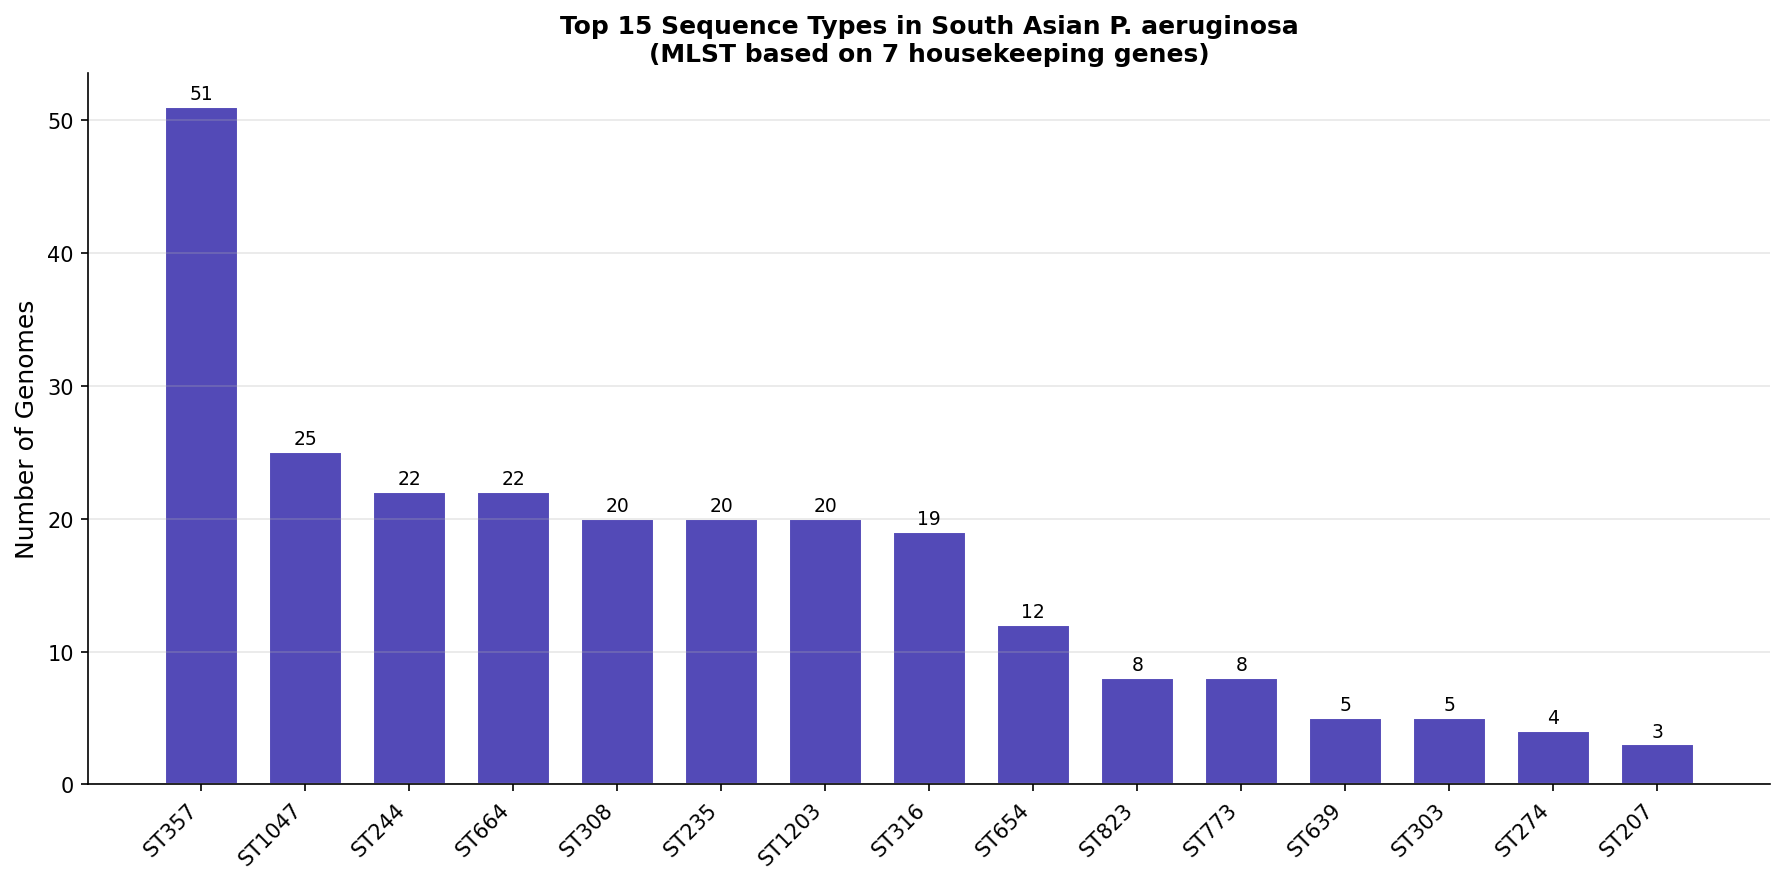

Figure 7 saved


In [17]:
# CELL 15: MLST — SEQUENCE TYPE DISTRIBUTION
# ============================================================

# Get ST counts — exclude ND
st_counts = (meta_clinical[meta_clinical['ST'] != 'ND']['ST']
             .value_counts().head(15).reset_index())
st_counts.columns = ['ST', 'Count']
st_counts['ST_label'] = 'ST' + st_counts['ST']

print(f"Total genomes with ST assigned: {(meta_clinical['ST'] != 'ND').sum()}")
print(f"\nTop 15 Sequence Types:")
print(st_counts.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(range(len(st_counts)), st_counts['Count'],
              color='#534AB7', edgecolor='white', width=0.7)

ax.set_xticks(range(len(st_counts)))
ax.set_xticklabels(st_counts['ST_label'], rotation=45, ha='right', fontsize=10)
ax.set_ylabel('Number of Genomes', fontsize=12)
ax.set_title('Top 15 Sequence Types in South Asian P. aeruginosa\n'
             '(MLST based on 7 housekeeping genes)',
             fontsize=12, fontweight='bold')

for bar, val in zip(bars, st_counts['Count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(val), ha='center', va='bottom', fontsize=9)

ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUT_PATH}/Fig7_ST_Distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 7 saved")

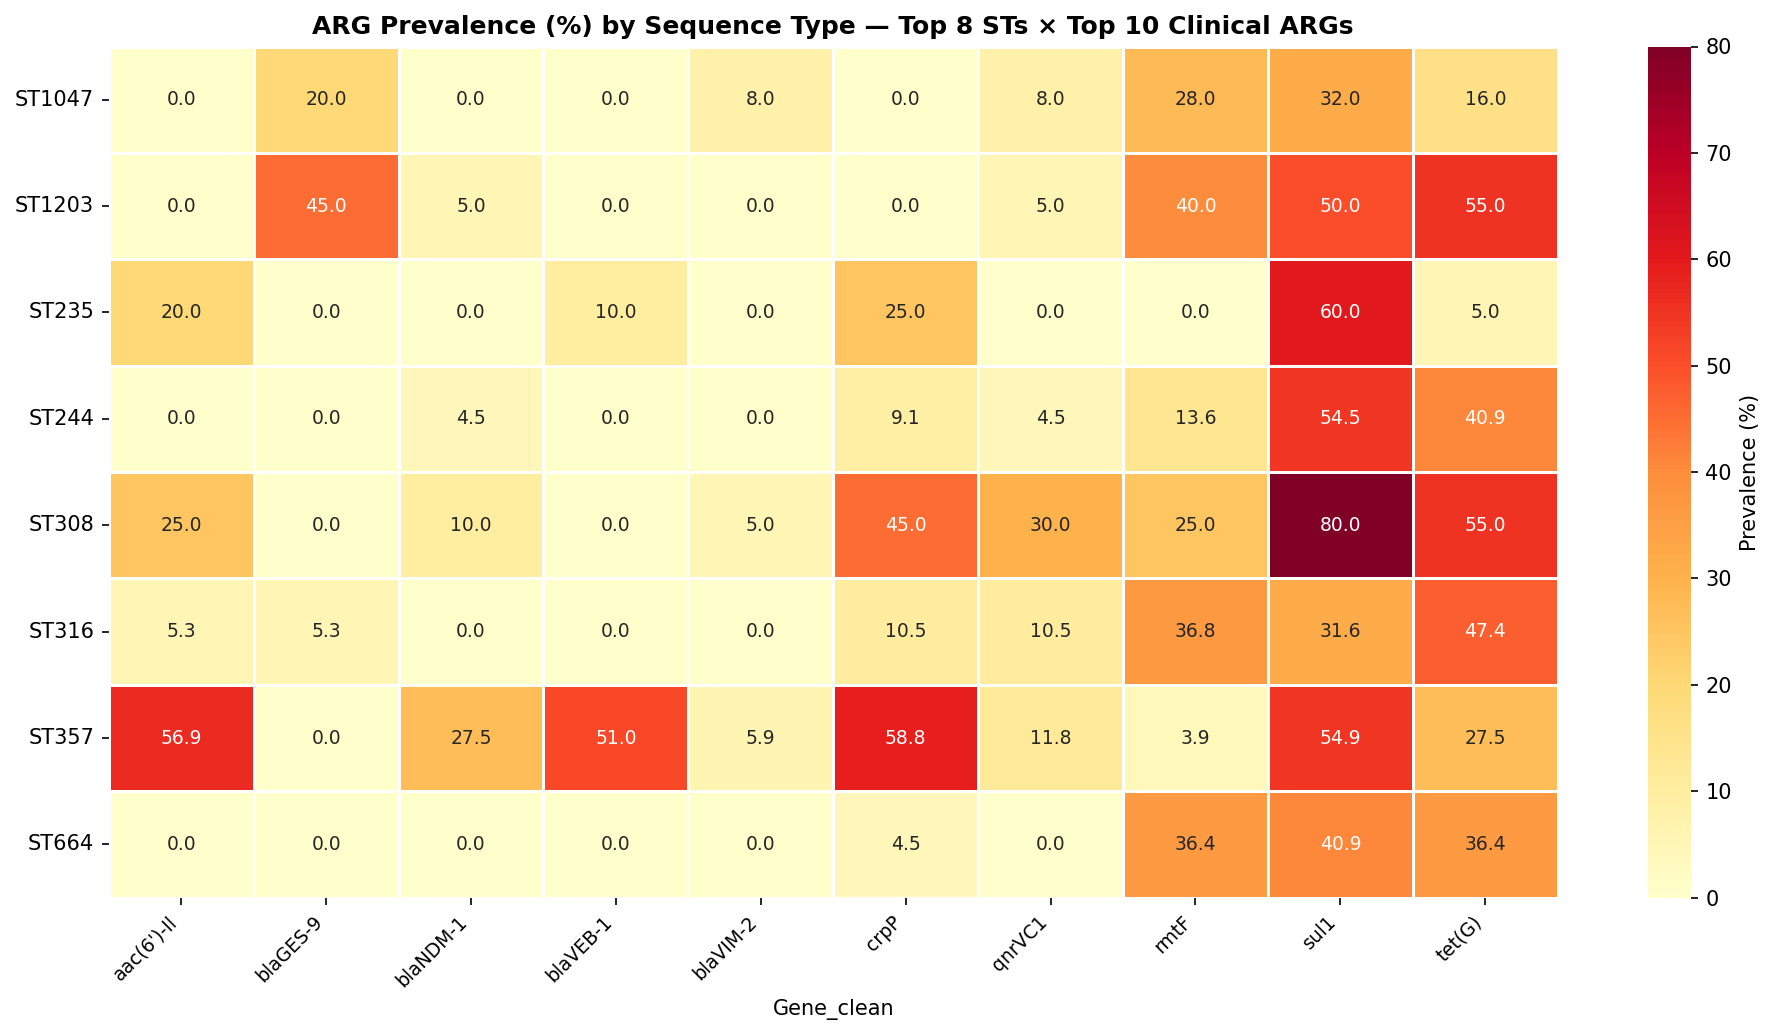

Figure 8 saved


In [18]:
# CELL 16: ST-ARG PREVALENCE HEATMAP
# ============================================================

# Top 8 STs and top 10 clinical ARGs
top8_sts = st_counts['ST'].head(8).tolist()

top10_clinical = ['blaNDM-1', 'blaVIM-2', 'rmtF', 'sul1', 'tet(G)',
                  'qnrVC1', 'blaGES-9', 'blaVEB-1', 'crpP', "aac(6')-Il"]

# Filter rf for these STs and genes
rf_st = rf[rf['ST'].isin(top8_sts) & rf['Gene_clean'].isin(top10_clinical)].copy()

# Calculate prevalence per ST
st_totals = meta_clinical[meta_clinical['ST'].isin(top8_sts)]['ST'].value_counts()

st_arg = (rf_st.groupby(['ST', 'Gene_clean'])['GCA']
          .nunique().reset_index(name='Count'))

st_arg['Total'] = st_arg['ST'].map(st_totals)
st_arg['Prevalence'] = st_arg['Count'] / st_arg['Total'] * 100

pivot_st = st_arg.pivot(index='ST', columns='Gene_clean',
                        values='Prevalence').fillna(0)
pivot_st.index = ['ST' + str(i) for i in pivot_st.index]

fig, ax = plt.subplots(figsize=(13, 7))
sns.heatmap(pivot_st, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Prevalence (%)'},
            annot_kws={'size': 9})

ax.set_title('ARG Prevalence (%) by Sequence Type — Top 8 STs × Top 10 Clinical ARGs',
             fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.savefig(f'{OUT_PATH}/Fig8_ST_ARG_Heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 8 saved")

Total genomes with CC assigned: 254

Top 15 Clonal Complexes:
    CC  Count
 CC357     51
CC1047     25
 CC664     22
 CC244     22
 CC308     20
CC1203     20
 CC235     20
 CC316     19
 CC654     12
 CC823      8
 CC773      8
 CC639      5
 CC303      5
 CC274      4
 CC111      3


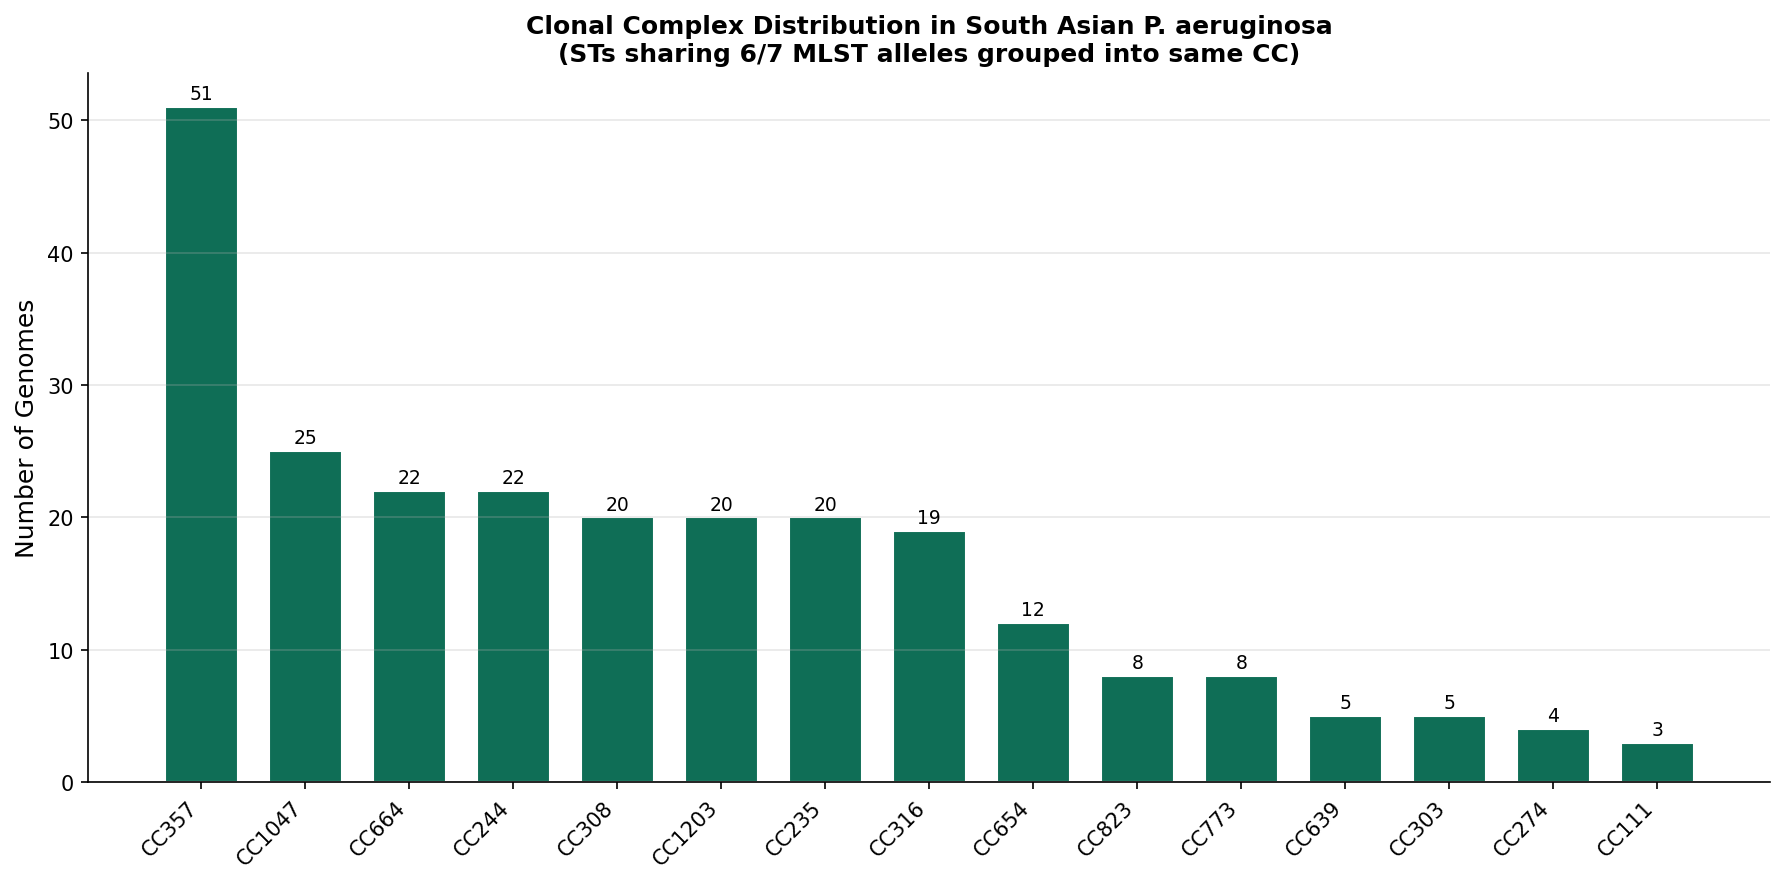

Figure 9 saved


In [19]:
# CELL 17: CLONAL COMPLEX DISTRIBUTION
# ============================================================

cc_counts = (meta_clinical[meta_clinical['CC'] != 'ND']['CC']
             .value_counts().head(15).reset_index())
cc_counts.columns = ['CC', 'Count']

print(f"Total genomes with CC assigned: {(meta_clinical['CC'] != 'ND').sum()}")
print(f"\nTop 15 Clonal Complexes:")
print(cc_counts.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(range(len(cc_counts)), cc_counts['Count'],
              color='#0F6E56', edgecolor='white', width=0.7)

ax.set_xticks(range(len(cc_counts)))
ax.set_xticklabels(cc_counts['CC'], rotation=45, ha='right', fontsize=10)
ax.set_ylabel('Number of Genomes', fontsize=12)
ax.set_title('Clonal Complex Distribution in South Asian P. aeruginosa\n'
             '(STs sharing 6/7 MLST alleles grouped into same CC)',
             fontsize=12, fontweight='bold')

for bar, val in zip(bars, cc_counts['Count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(val), ha='center', va='bottom', fontsize=9)

ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUT_PATH}/Fig9_CC_Distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 9 saved")

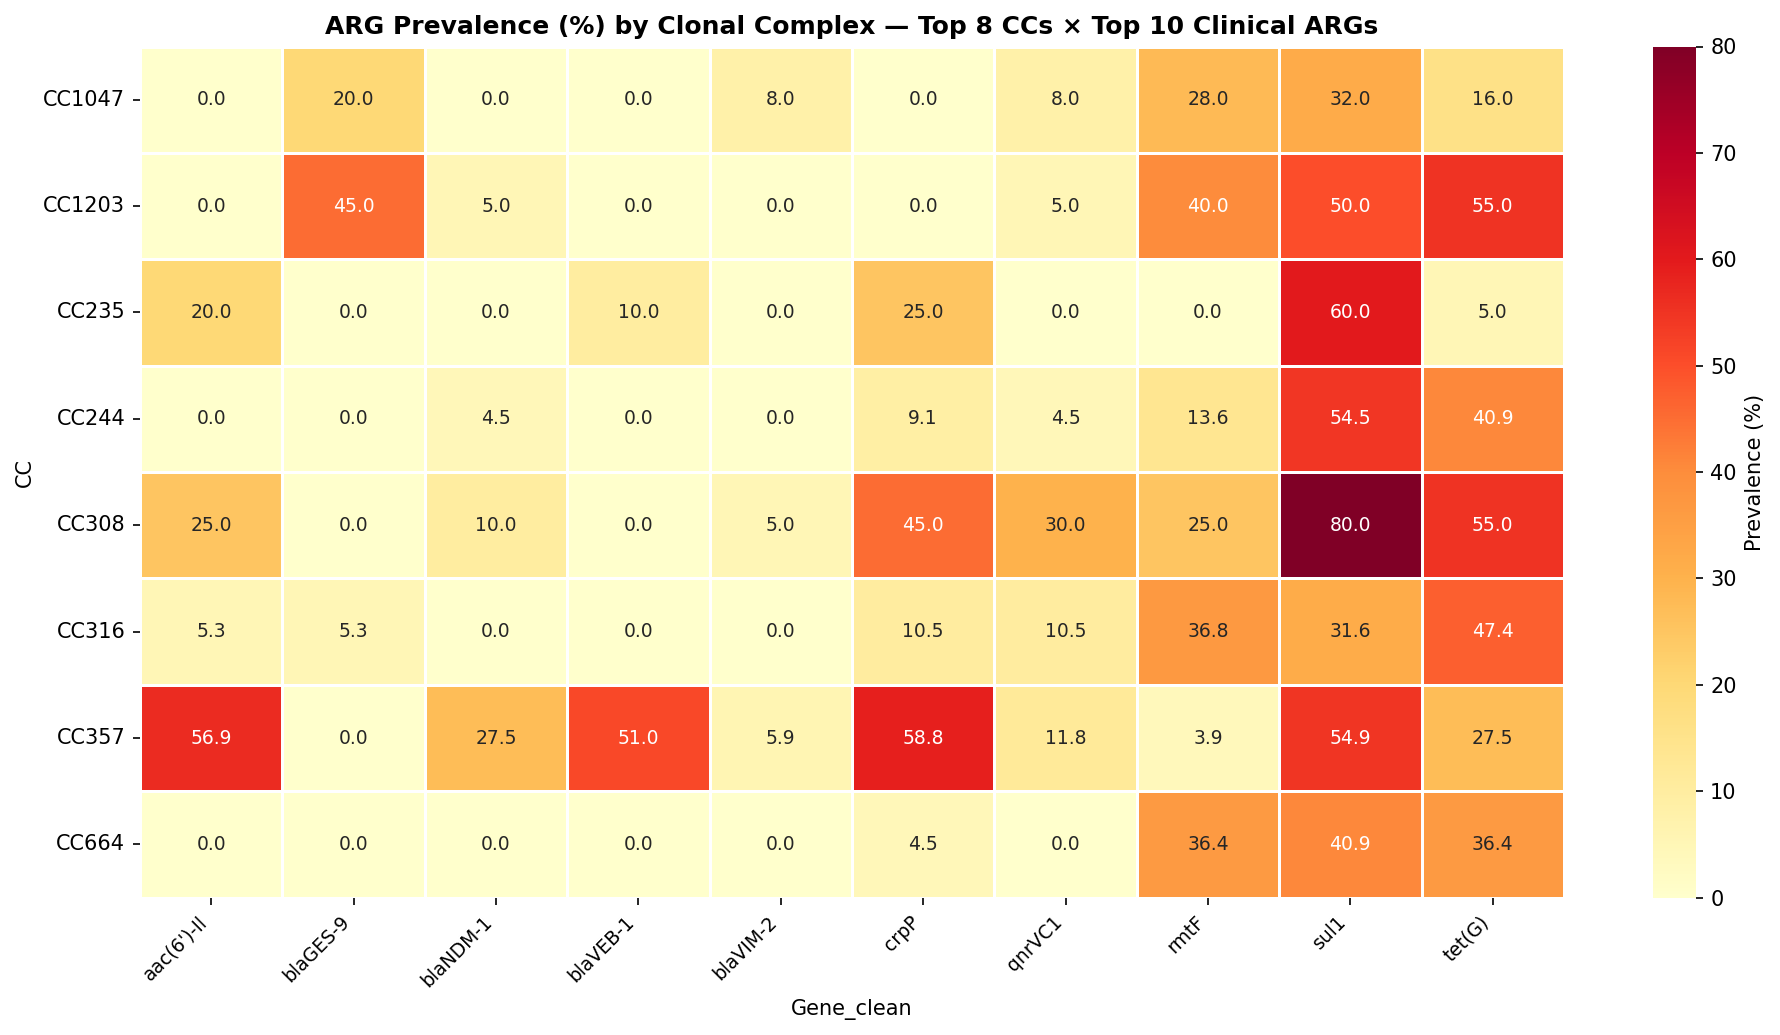

Figure 10 saved


In [20]:
# CELL 18: CC-ARG PREVALENCE HEATMAP
# ============================================================

top8_ccs = cc_counts['CC'].head(8).tolist()

rf_cc = rf[rf['CC'].isin(top8_ccs) & rf['Gene_clean'].isin(top10_clinical)].copy()

cc_totals = meta_clinical[meta_clinical['CC'].isin(top8_ccs)]['CC'].value_counts()

cc_arg = (rf_cc.groupby(['CC', 'Gene_clean'])['GCA']
          .nunique().reset_index(name='Count'))

cc_arg['Total'] = cc_arg['CC'].map(cc_totals)
cc_arg['Prevalence'] = cc_arg['Count'] / cc_arg['Total'] * 100

pivot_cc = cc_arg.pivot(index='CC', columns='Gene_clean',
                        values='Prevalence').fillna(0)

fig, ax = plt.subplots(figsize=(13, 7))
sns.heatmap(pivot_cc, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Prevalence (%)'},
            annot_kws={'size': 9})

ax.set_title('ARG Prevalence (%) by Clonal Complex — Top 8 CCs × Top 10 Clinical ARGs',
             fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.savefig(f'{OUT_PATH}/Fig10_CC_ARG_Heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 10 saved")

In [21]:
# CELL 19: SUMMARY RESULTS TABLE
# ============================================================

print("=" * 60)
print("COMPLETE ANALYSIS SUMMARY")
print("=" * 60)

print(f"\n--- Dataset ---")
print(f"Total genomes in metadata:        {len(meta_clinical)}")
print(f"FASTA files analysed by StarAMR:  281")
print(f"Genomes with acquired ARGs:       {rf['GCA'].nunique()} ({rf['GCA'].nunique()/281*100:.1f}%)")
print(f"Total ARG detections:             {len(rf)}")
print(f"Unique acquired ARGs:             {rf['Gene_clean'].nunique()}")

print(f"\n--- Top 5 Most Prevalent ARGs ---")
top5 = rf['Gene_clean'].value_counts().head(5)
for gene, count in top5.items():
    print(f"  {gene:<25} {count} genomes ({count/281*100:.1f}%)")

print(f"\n--- Key Clinical ARGs ---")
clinical_genes = {
    'blaNDM-1': 'Carbapenem resistance',
    'rmtF': 'Pan-aminoglycoside resistance',
    'qnrVC1': 'Fluoroquinolone resistance',
    'blaVIM-2': 'Carbapenem resistance',
    'blaGES-9': 'Emerging carbapenemase',
    'blaVEB-1': 'Extended spectrum beta-lactamase',
}
for gene, desc in clinical_genes.items():
    count = rf[rf['Gene_clean'] == gene]['GCA'].nunique()
    print(f"  {gene:<15} {count:>3} genomes ({count/281*100:.1f}%)  — {desc}")

print(f"\n--- Drug Class Summary ---")
dc = rf[rf['DrugClass'] != 'other']['DrugClass'].value_counts()
for cls, count in dc.items():
    print(f"  {cls:<20} {count} detections")

print(f"\n--- Temporal Summary ---")
print(f"  MDR burden range: {mdr_trend['MeanDrugClasses'].min():.2f} - {mdr_trend['MeanDrugClasses'].max():.2f} drug classes/genome")
print(f"  Kruskal-Wallis p = {p_time:.4f} — MDR is endemic and stable")

print(f"\n--- MLST Summary ---")
print(f"  Genomes with ST assigned:  {(meta_clinical['ST'] != 'ND').sum()}")
print(f"  Dominant ST:               ST357 (n=51, 18.1%)")
print(f"  High-risk clone ST235:     n=20 (7.1%)")
print(f"  Genomes with CC assigned:  {(meta_clinical['CC'] != 'ND').sum()}")

print(f"\n--- Emerging ARGs ---")
print(f"  rmtF:   {rf[rf['Gene_clean']=='rmtF']['GCA'].nunique()} genomes (19.3%) — appears from 2010 onwards")
print(f"  qnrVC1: {rf[rf['Gene_clean']=='qnrVC1']['GCA'].nunique()} genomes (11.1%) — appears from 2010 onwards")

print(f"\n--- Figures Generated ---")
figures = ['Fig1_Top20_ARGs', 'Fig2_Temporal_Trends', 'Fig3_Geographic_Distribution',
           'Fig4_Cooccurrence_Heatmap', 'Fig5_Chord_Diagram', 'Fig6_MDR_Burden_Trend',
           'Fig7_ST_Distribution', 'Fig8_ST_ARG_Heatmap', 'Fig9_CC_Distribution',
           'Fig10_CC_ARG_Heatmap']
for f in figures:
    print(f"  {f}.png")

print(f"\n{'=' * 60}")
print("Analysis complete.")
print("=" * 60)

COMPLETE ANALYSIS SUMMARY

--- Dataset ---
Total genomes in metadata:        396
FASTA files analysed by StarAMR:  281
Genomes with acquired ARGs:       201 (71.5%)
Total ARG detections:             1549
Unique acquired ARGs:             94

--- Top 5 Most Prevalent ARGs ---
  sul1                      190 genomes (67.6%)
  tet(G)                    98 genomes (34.9%)
  CmlA9                     96 genomes (34.2%)
  aph(3'')-Ib               82 genomes (29.2%)
  aph(6)-Id                 81 genomes (28.8%)

--- Key Clinical ARGs ---
  blaNDM-1         35 genomes (12.5%)  — Carbapenem resistance
  rmtF             54 genomes (19.2%)  — Pan-aminoglycoside resistance
  qnrVC1           31 genomes (11.0%)  — Fluoroquinolone resistance
  blaVIM-2         15 genomes (5.3%)  — Carbapenem resistance
  blaGES-9         22 genomes (7.8%)  — Emerging carbapenemase
  blaVEB-1         32 genomes (11.4%)  — Extended spectrum beta-lactamase

--- Drug Class Summary ---
  aminoglycoside       559 detec